In [2]:
#Лабораторная работа №9 Горьков Антон 5130901/30201
# Глава 9. Дифференцирование и интегрирование

In [3]:
# Упражнение 9.1
#В разделе «Нарастающая сумма» н а стр. 119 отмечено, ч т о некото-
#рые примеры не работают с апериодическими сигналами. Замените
#периодический пилообразный сигнал н а непериодические данные
#Facebook и посмотрите, ч т о пойдет не так.

In [6]:
#Ответ: Для непериодических данных Facebook интегрирование через спектр дает артефакты из-за разрывов 
#на концах и ложного предположения периодичности.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

In [4]:
# Упражнение 9.2
#
# В этом упражнении изучается влияние diff и differentiate на сигнал.
# Создайте треугольный сигнал и напечатайте его.
# Примените diff к сигналу и напечатайте результат.
# Вычислите спектр треугольного сигнала, примените differentiate
# и напечатайте результат.
# Преобразуйте спектр обратно в сигнал и напечатайте его.
#
# Есть ли различия в воздействии diff и differentiate на этот сигнал?

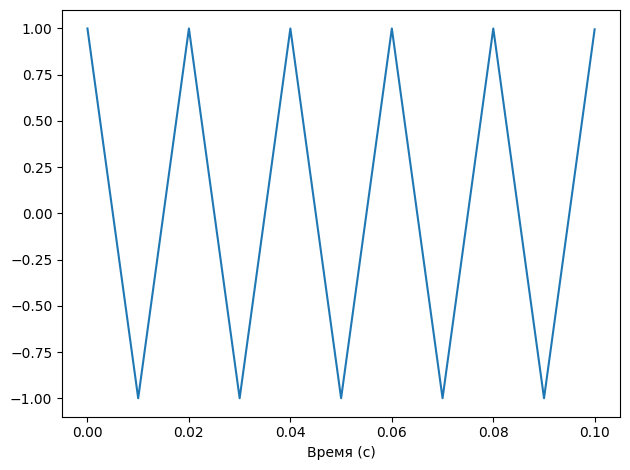

In [5]:
# Треугольный сигнал.

from thinkdsp import TriangleSignal

in_wave = TriangleSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Время (с)')

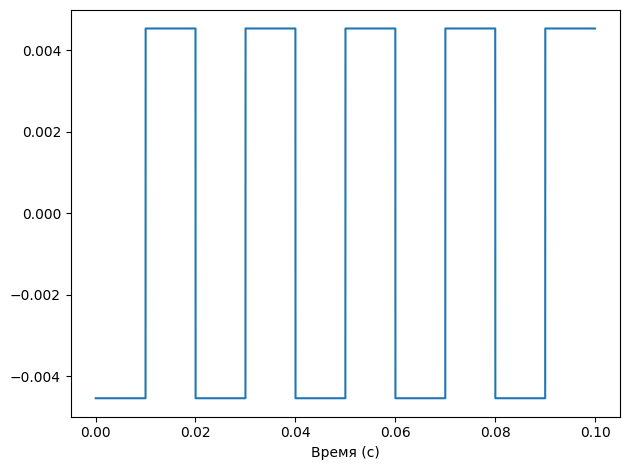

In [6]:
# Применим конечную разность.
# Получили прямоугольный сигнал.

out_wave = in_wave.diff()
out_wave.plot()
decorate(xlabel='Время (с)')

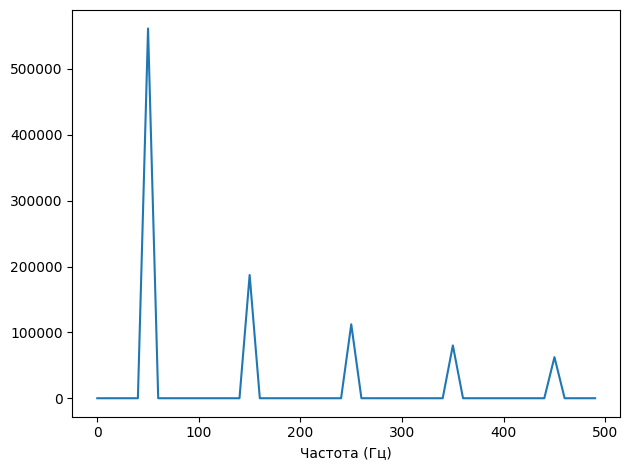

In [7]:
# Теперь вычислим спектр исходного сигнала,
# применим спектральную производную и посмотрим на результат.

spectrum = in_wave.make_spectrum().differentiate()
spectrum.plot(high=500)
decorate(xlabel='Частота (Гц)')

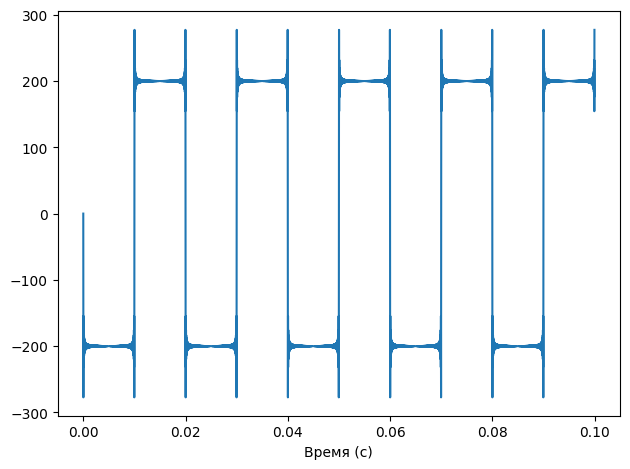

In [8]:
# Преобразуем спектр обратно в сигнал.
# С математической точки зрения, проблема заключается в том, что производная треугольной волны не определена в точках треугольника
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Время (с)')

In [9]:
#Выводы:
# 1. Оператор diff превращает треугольный сигнал в сигнал,
#    похожий на прямоугольный.
# 2. Спектральная производная дает похожий результат,
#    но около точек излома появляются колебания.
# 3. Эти колебания возникают потому, что производная треугольного сигнала
#    в точках излома не определена.

In [10]:
# Упражнение 9.3
#
# В данном упражнении изучается влияние cumsum и integrate на сигнал.
# Создайте прямоугольный сигнал и напечатайте его.
# Примените cumsum и напечатайте результат.
# Вычислите спектр прямоугольного сигнала, примените integrate
# и напечатайте результат.
# Преобразуйте спектр обратно в сигнал и напечатайте его.
#
# Есть ли различия в воздействии cumsum и integrate на этот сигнал?

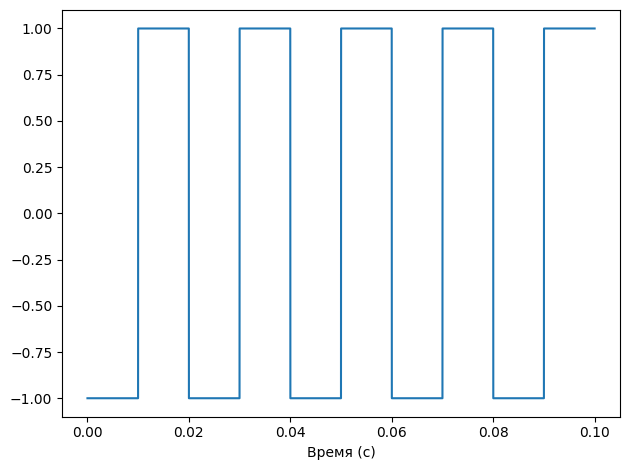

In [11]:
# Вот прямоугольный сигнал.

from thinkdsp import SquareSignal

in_wave = SquareSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Время (с)')

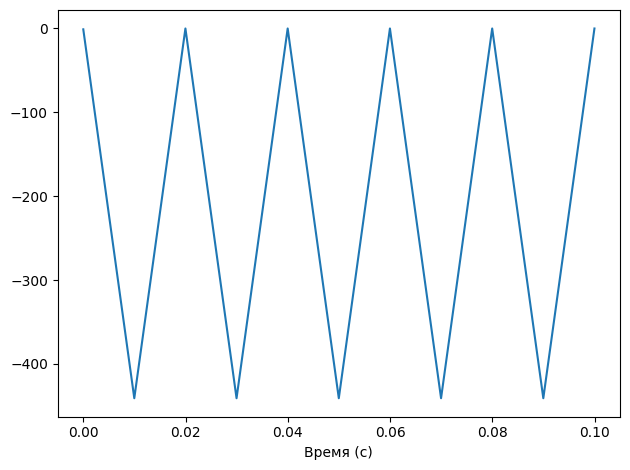

In [12]:
# Применим накопленную сумму.

out_wave = in_wave.cumsum()
out_wave.plot()
decorate(xlabel='Время (с)')

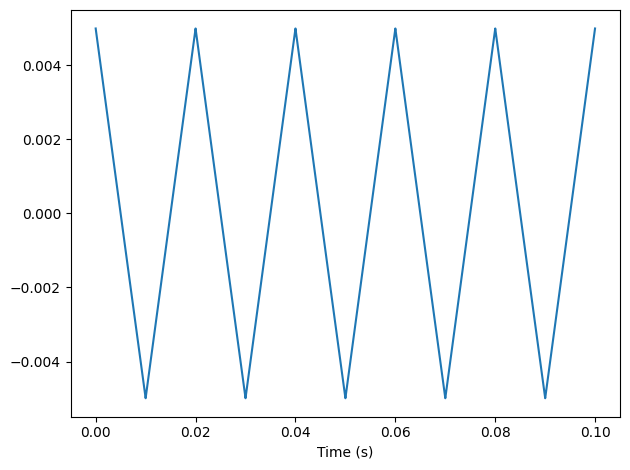

In [13]:
# Теперь вычислим спектр исходного сигнала,
# Применим спектральное интегрирование и преобразуем обратно в сигнал

spectrum = in_wave.make_spectrum().integrate()
spectrum.hs[0] = 0
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Time (s)')

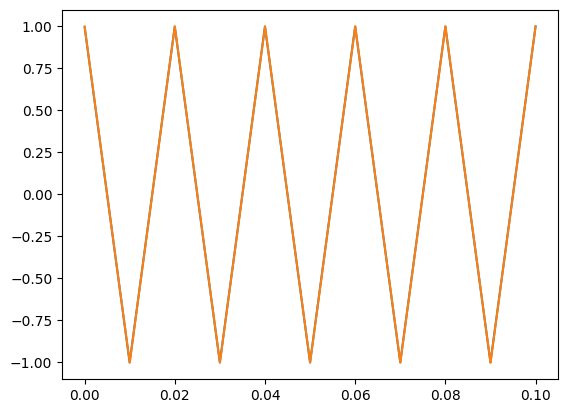

In [14]:
#Если мы устраним искажения и нормализуем обе волны, то визуально они окажутся похожими.
out_wave.unbias()
out_wave.normalize()
out_wave2.normalize()
out_wave.plot()
out_wave2.plot()

In [15]:
#Выводы:
# 1. Оператор cumsum превращает прямоугольный сигнал
#    в сигнал, похожий на треугольный.
# 2. Спектральное интегрирование integrate дает похожий результат.
# 3. Однако результаты не полностью совпадают по масштабу и смещению,
#    поэтому перед сравнением полезно убрать среднее и нормализовать сигнал.
# 4. Основная форма в обоих случаях одинаковая:
#    интегрирование прямоугольного сигнала дает треугольный сигнал.
# 5. cumsum и integrate численно схожи, но с точностью до 3 знаков после запятой.
out_wave.max_diff(out_wave2)

np.float64(0.0045351473922902175)

In [16]:
# Упражнение 9.4
#
# В данном упражнении изучается влияние двойного интегрирования.
# Создайте пилообразный сигнал, вычислите его спектр,
# а затем дважды примените integrate.
#
# Напечатайте результирующий сигнал и его спектр.
# Какова математическая форма сигнала?
# Почему он напоминает синусоиду?

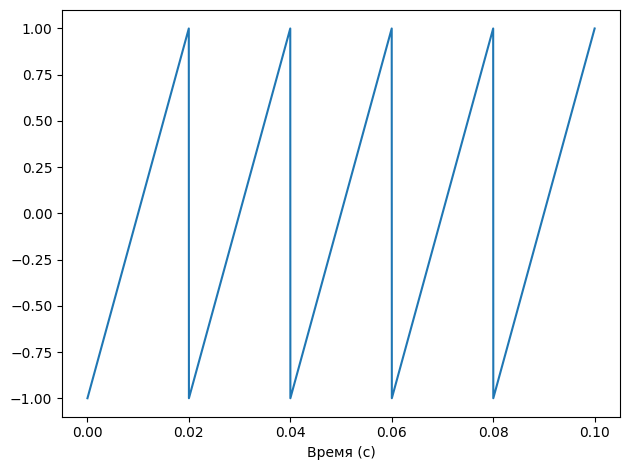

In [17]:
# Пилообразный сигнал.

from thinkdsp import SawtoothSignal

in_wave = SawtoothSignal(freq=50).make_wave(duration=0.1, framerate=44100)
in_wave.plot()
decorate(xlabel='Время (с)')

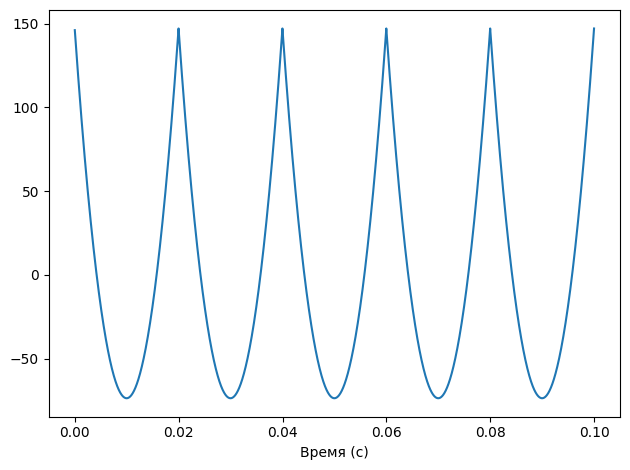

In [18]:
#Результат применения cumsum первый раз - парабола 

out_wave = in_wave.cumsum()
out_wave.unbias()
out_wave.plot()
decorate(xlabel='Время (с)')

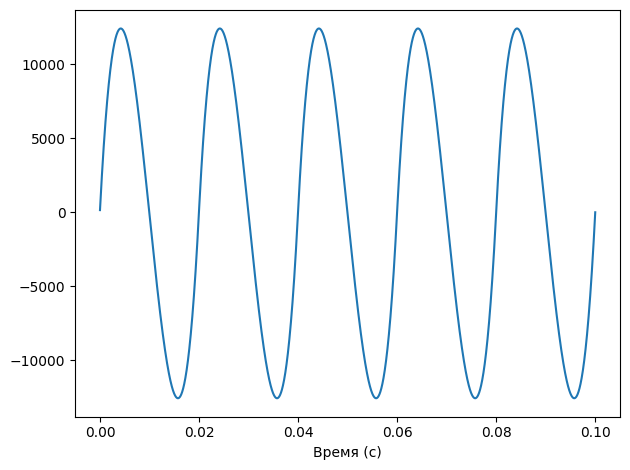

In [19]:
#Результат применения cumsum второй раз - кубическая кривая 

out_wave = out_wave.cumsum()
out_wave.plot()
decorate(xlabel='Время (с)')

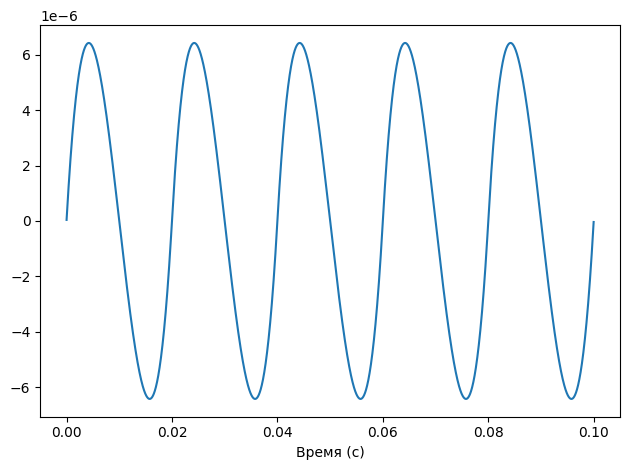

In [20]:
#Дважды интегрируем нашу кубическую кривую 
spectrum = in_wave.make_spectrum().integrate().integrate()
spectrum.hs[0] = 0
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Время (с)')

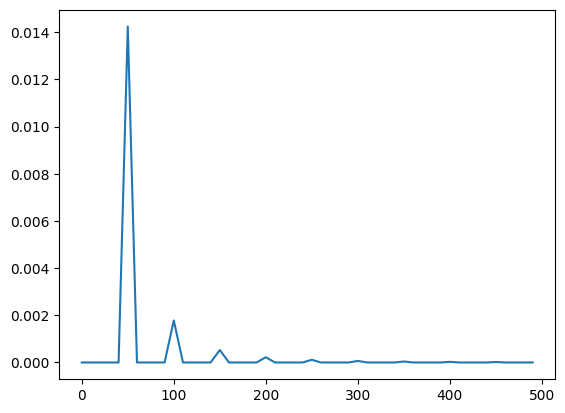

In [21]:
out_wave2.make_spectrum().plot(high=500)

In [22]:
# Выводы:
# 1. После двойного интегрирования форма сигнала становится гладкой
#    и близкой к параболической между периодами.
# 2. Но визуально сигнал напоминает синусоиду, потому что
#    высокочастотные гармоники сильно подавляются.
# 3. Каждый вызов integrate делит гармоники на частоту,
#    поэтому после двух вызовов амплитуды уменьшаются как 1 / f^2.
# 4. Из-за этого в сигнале начинает доминировать первая гармоника.
# 5. Когда в спектре доминирует первая гармоника, сигнал выглядит почти синусоидальным.

In [23]:
# Упражнение 9.5
#
# В этом упражнении изучается влияние второй разности и второй
# производной.
#
# Создайте CubicSignal, определенный в thinkdsp.
# Вычислите вторую разность, дважды применив diff.
# Как выглядит результат?
#
# Вычислите вторую производную, дважды применив differentiate
# к спектру. Похожи ли результаты?
#
# Распечатайте фильтры, соответствующие второй разности и второй
# производной, и сравните их.
#
# Подсказка: чтобы получить фильтры в одном масштабе,
# используйте сигнал с частотой кадров 1.

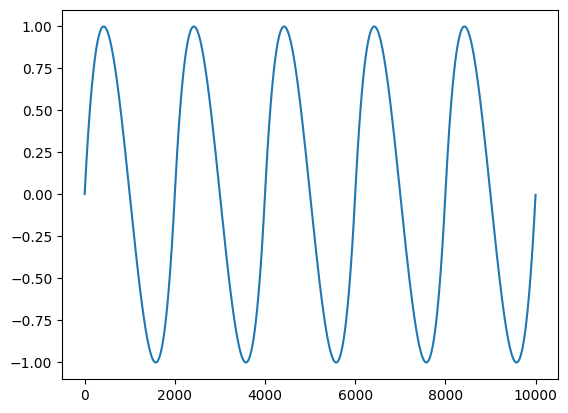

In [24]:
from thinkdsp import CubicSignal

in_wave = CubicSignal(freq=0.0005).make_wave(duration=10000, framerate=1)
in_wave.plot()

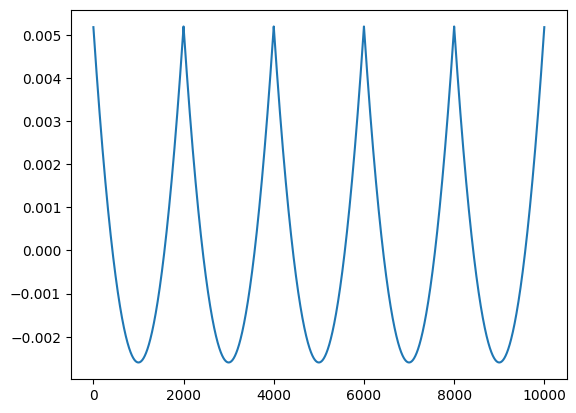

In [25]:
out_wave = in_wave.diff()
out_wave.plot()

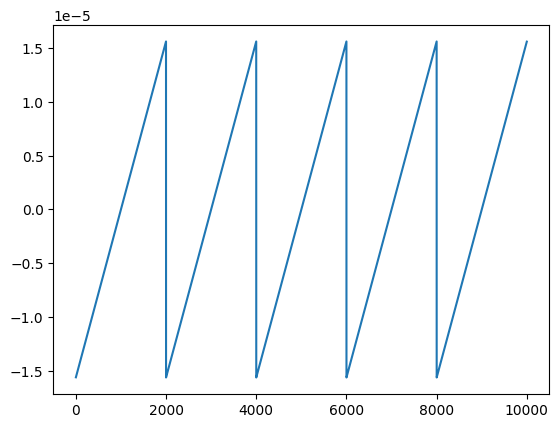

In [26]:
#Результат похож на пилообразный сигнал

out_wave = out_wave.diff()
out_wave.plot()

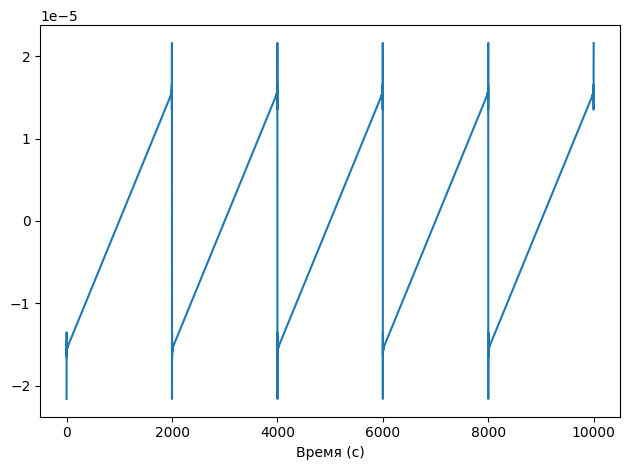

In [28]:
#Получили пилообразный сигнал. Но в точках производная неопределена и получились искажения

spectrum = in_wave.make_spectrum().differentiate().differentiate()
out_wave2 = spectrum.make_wave()
out_wave2.plot()
decorate(xlabel='Время (с)')

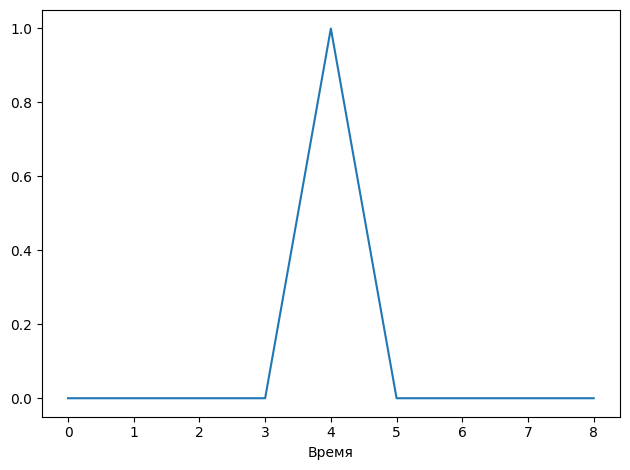

In [39]:
# Теперь исследуем фильтр второй разности.
# Для этого подадим единичный импульс и посмотрим результат.


from thinkdsp import Impulses

impulse = Impulses([4]).make_wave(start=0, duration=9, framerate=1)
impulse.plot()
decorate(xlabel='Время')

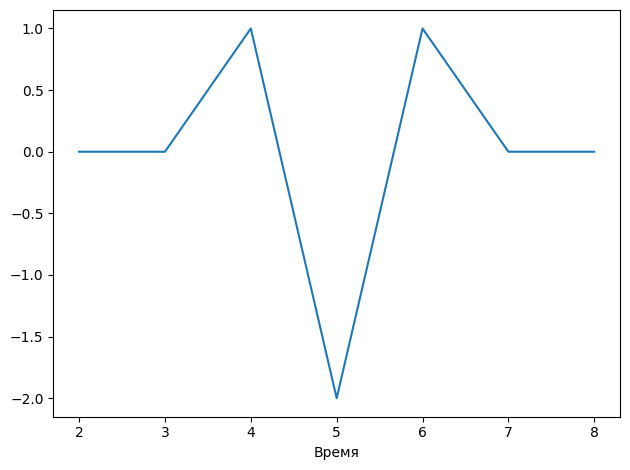

In [40]:
# Фильтр, соответствующий второй разности.

filter_diff2 = impulse.diff().diff()
filter_diff2.plot()
decorate(xlabel='Время')

In [41]:
print(filter_diff2.ys)

[ 0.  0.  1. -2.  1.  0.  0.]


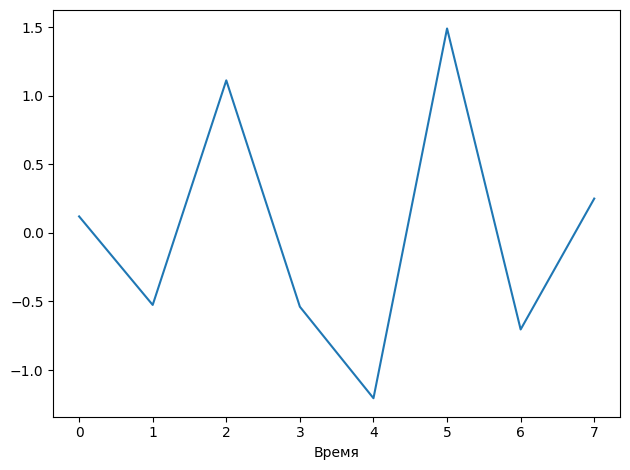

In [42]:
# Фильтр, соответствующий второй производной в спектральной области.

spectrum = impulse.make_spectrum()
filter_diffspec = spectrum.differentiate().differentiate().make_wave()

filter_diffspec.plot()
decorate(xlabel='Время')

In [43]:
print(np.round(filter_diffspec.ys, 4))

[ 0.1202 -0.5252  1.1121 -0.5383 -1.2054  1.4903 -0.7039  0.2502]


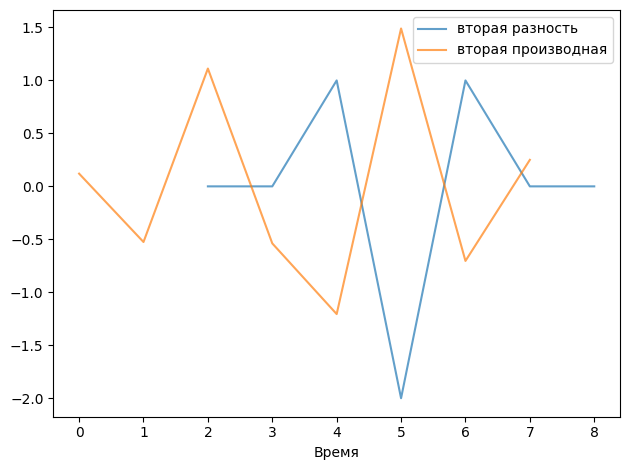

In [44]:
# Сравним оба фильтра на одном графике.

filter_diff2.plot(label='вторая разность', alpha=0.7)
filter_diffspec.plot(label='вторая производная', alpha=0.7)
decorate(xlabel='Время')
plt.legend()

In [45]:
# Посмотрим только на первые несколько отсчетов.

print('Фильтр второй разности:')
print(np.round(filter_diff2.ys[:8], 4))

print()

print('Фильтр второй производной:')
print(np.round(filter_diffspec.ys[:8], 4))

Фильтр второй разности:
[ 0.  0.  1. -2.  1.  0.  0.]

Фильтр второй производной:
[ 0.1202 -0.5252  1.1121 -0.5383 -1.2054  1.4903 -0.7039  0.2502]


In [46]:
# Выводы:
# 1. Фильтр второй разности локальный и короткий:
#    его коэффициенты имеют вид [1, -2, 1].
# 2. Фильтр второй производной в спектральной форме не локален:
#    он распределен по многим отсчетам.
# 3. Оба фильтра реализуют похожую идею — выделение кривизны сигнала.
# 4. Но вторая разность — это дискретное локальное приближение,
#    а спектральная вторая производная — глобальная операция.